# Load spatialdata object

In [22]:
import anndata as ad
import spatialdata as sd
import spatialdata_plot  # noqa: F401
import matplotlib.pyplot as plt

We read the MIBI-tof data. We use spatialdata readers for this

In [2]:
sdata=sd.read_zarr('../../../data/cycif.zarr')

/opt/anaconda3/envs/sopa/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/opt/anaconda3/envs/sopa/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


This object contains one example image, with 12 channels, and two labels (from 2 segmentationds), one for nuclei and one for cell. Two cell tables are also presented


In [ ]:
sdata

SpatialData object, with associated Zarr store: /Users/sergio/Documents/jnotebooks/sprot_hackathon/data/cycif.zarr
├── Images
│     └── 'exemplar-001_image': DataArray[cyx] (12, 3139, 2511)
├── Labels
│     ├── 'exemplar-001_cell': DataArray[yx] (3139, 2511)
│     └── 'exemplar-001_nuclei': DataArray[yx] (3139, 2511)
└── Tables
      ├── 'exemplar-001--ilastik_cell': AnnData (11607, 12)
      └── 'exemplar-001--unmicst_cell': AnnData (11170, 12)
with coordinate systems:
    ▸ 'global', with elements:
        exemplar-001_image (Images), exemplar-001_cell (Labels), exemplar-001_nuclei (Labels)

We can see how the info of segmented cells looks like. 

In [7]:
sdata['exemplar-001--ilastik_cell'].obs

,CellID,Area,MajorAxisLength,MinorAxisLength,Eccentricity,Solidity,Extent,Orientation,region
0,1,115,12.375868,11.823117,0.295521,0.966387,0.798611,-1.104797,exemplar-001_cell
1,2,116,13.194022,11.409409,0.502218,0.928000,0.637363,-0.302594,exemplar-001_cell
2,3,275,25.707509,15.016083,0.811673,0.854037,0.543478,-0.843245,exemplar-001_cell
3,4,153,15.177227,14.502433,0.294865,0.864407,0.562500,-0.869925,exemplar-001_cell
4,5,119,13.380833,11.341761,0.530616,0.929688,0.762821,1.262365,exemplar-001_cell
...,...,...,...,...,...,...,...,...,...
11602,11603,182,21.136680,11.433784,0.841058,0.933333,0.722222,-1.372091,exemplar-001_cell
11603,11604,107,15.688602,9.473593,0.797096,0.856000,0.557292,-1.045656,exemplar-001_cell
11604,11605,161,19.816209,10.711573,0.841314,0.936047,0.670833,-1.315911,exemplar-001_cell
11605,11606,44,10.162652,5.904321,0.813916,0.880000,0.628571,-0.273928,exemplar-001_cell


We can extract image info using

In [36]:
img_array=sdata['exemplar-001_image'].values
channel_name=sdata['exemplar-001_image'].c.data
print(channel_name)

['DNA_6' 'ELANE' 'CD57' 'CD45' 'DNA_7' 'CD11B' 'SMA' 'CD16' 'DNA_8' 'ECAD'
 'FOXP3' 'NCAM']


We have some basic visualization

In [51]:

import matplotlib.pyplot as plt

def plot_channels(img_array, channel_names, roi=None, cmap="Greys"):
    """
    Plot multiple channels from a numpy image array in subplots.

    Parameters
    ----------
    img_array : np.ndarray
        Shape (channels, y, x)
    channel_names : list of str
        Names of channels to plot
    roi : tuple or None
        (x_min, x_max, y_min, y_max) in pixel coordinates. If None, plot full image.
    cmap : str
        Colormap for imshow
    """
    n_channels = len(channel_names)
    fig, axes = plt.subplots(1, n_channels, figsize=(4*n_channels, 4))

    if n_channels == 1:
        axes = [axes]  # ensure iterable

    for ax, idx in zip(axes, range(n_channels)):
        # Extract channel
        ch_img = img_array[idx, :, :]

        # Apply ROI
        if roi is not None:
            x_min, x_max, y_min, y_max = roi
            ch_img = ch_img[y_min:y_max, x_min:x_max]

        ax.imshow(ch_img, cmap=cmap)
        ax.set_title(channel_names[idx])
        ax.axis("off")

    plt.tight_layout()
    plt.show()


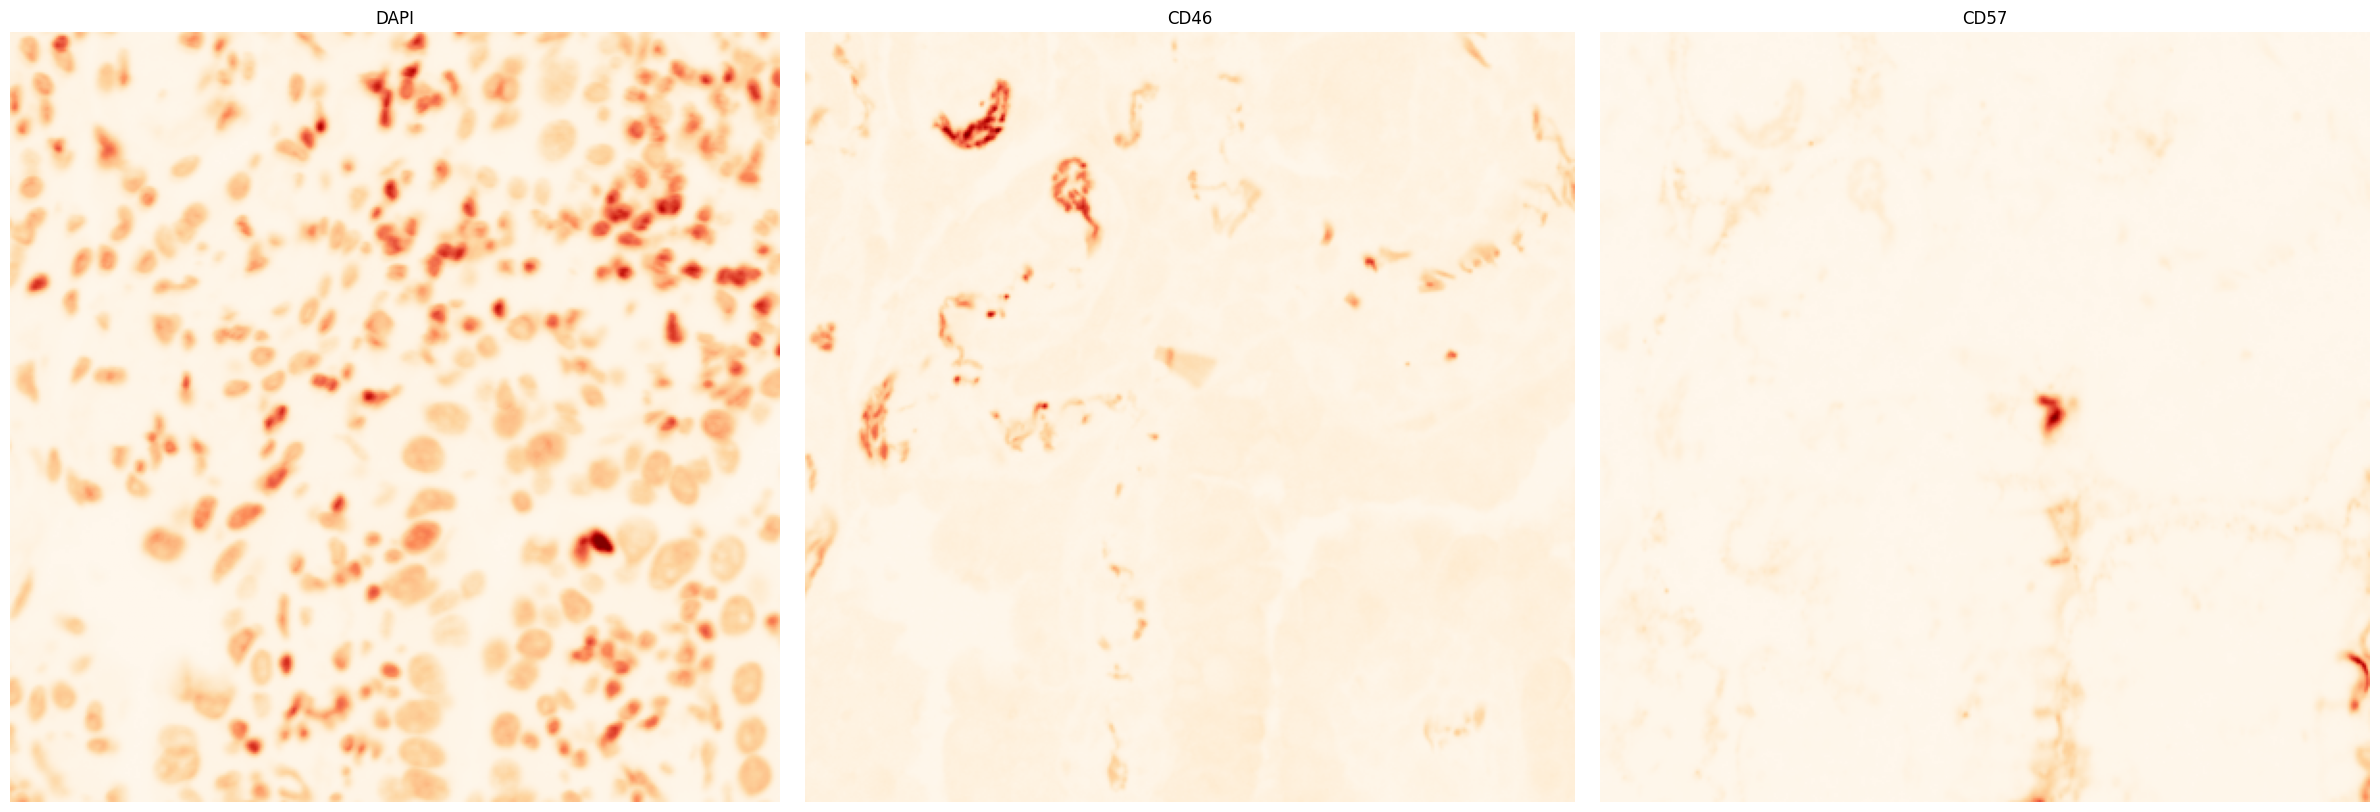

In [50]:
img_array = sdata['exemplar-001_image'].data  # numpy array
channels = ["DAPI", "CD46", "CD57"]
roi = (1500, 1900, 1500, 1900)   # x_min, x_max, y_min, y_max

plot_channels(img_array, channels, roi,cmap='OrRd')


array(['DNA_6', 'ELANE', 'CD57', 'CD45', 'DNA_7', 'CD11B', 'SMA', 'CD16',
       'DNA_8', 'ECAD', 'FOXP3', 'NCAM'], dtype='<U5')

# Data distribution

In [54]:
adata=sdata['exemplar-001--ilastik_cell']

In [61]:
adata.var.index

Index(['DNA_6', 'ELANE', 'CD57', 'CD45', 'DNA_7', 'CD11B', 'SMA', 'CD16',
       'DNA_8', 'ECAD', 'FOXP3', 'NCAM'],
      dtype='object', name='marker_name')

In [65]:
import matplotlib.pyplot as plt

def plot_gene_histogram(adata, gene, bins=100):
    """
    Plot histogram of expression values for one gene/channel in adata.

    Parameters
    ----------
    adata : AnnData
        AnnData object
    gene : str
        Gene name in adata.var.index
    bins : int
        Number of histogram bins
    """
    if gene not in adata.var.index:
        raise ValueError(f"{gene} not found in adata.var.index")

    # Get expression values for this gene
    values = adata[:, gene].X

    # If sparse, convert to dense
    if not hasattr(values, "toarray"):
        values = values
    else:
        values = values.toarray().flatten()

    plt.hist(values, bins=bins, color="steelblue", edgecolor="steelblue")
    plt.title(f"Expression distribution for {gene}")
    plt.xlabel("Expression value")
    plt.ylabel("Cell count")
    plt.show()


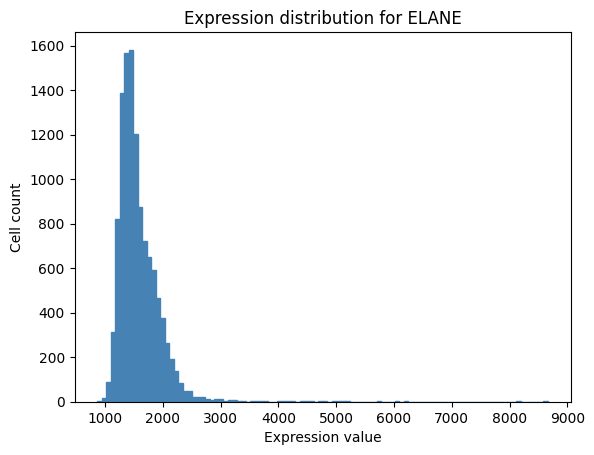

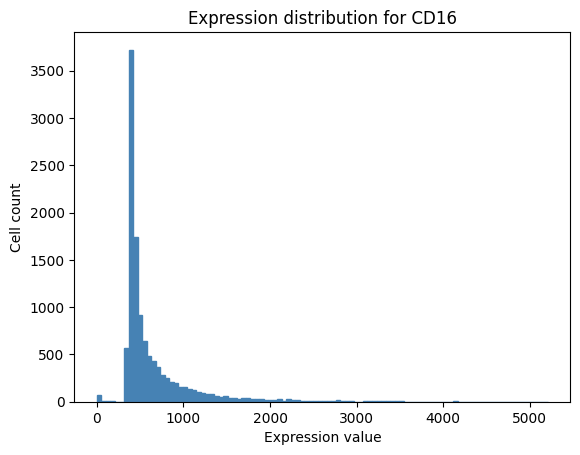

In [67]:
plot_gene_histogram(adata, "ELANE")   # replace "DAPI" with a gene/channel in your adata.var.index
plot_gene_histogram(adata, "CD16")   # replace "DAPI" with a gene/channel in your adata.var.index
